### Imports

In [31]:
import torch
import numpy as np
import pandas as pd
from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR_2, OUTPUT_DIR_2,
    F_L1, F_L5, EVENT_THRESHOLD_PERCENTILE, DELAY_EVENT_THRESHOLDS_M,
    PLOTS_DIR_2, GENERATED_PLOTS_DIR, get_date_label,
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer

from src.plots.loss_plots import (
    plot_lstm_loss, plot_transformer_loss,
)
from src.plots.prediction_plots import (
    plot_lstm_prediction, plot_transformer_prediction
)
from src.plots.delay_plots import (
    plot_lstm_delay_l1_l5_combined,
    plot_transformer_delay_l1_l5_combined,
)
from src.utils.iono_delay import delay_metrics, tec_to_iono_delay
from src.utils.save_results import save_delay_csv
from src.utils.metrics import (
    rmse,
    pearson_correlation,
    probability_of_detection,
    critical_success_index,
    f1_score,
    false_alarm_ratio,
)


---
# Dataset 2 — Day 40/41 Forecasting Workflow
---

### Base Directory and Output Setup — Dataset 2

In [32]:
print(f"Base directory 2  : {BASE_DIR_2}")
print(f"Output directory 2: {OUTPUT_DIR_2}")

Base directory 2  : c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2
Output directory 2: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet


### Creating Sorted TEC Dataset — Dataset 2
```text
Process folders iisc0910_TECU to iisc1310_TECU and create one sorted CSV
per folder containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [33]:
written_files_2 = build_sorted_dataset(2)

print("TEC data sorting completed — Dataset 2.")
print(f"Number of output CSV files written: {written_files_2}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_2}")

TEC data sorting completed — Dataset 2.
Number of output CSV files written: 41
Saved sorted CSV files to: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet


#### QUICK SANITY CHECK — Dataset 2
> Print first 6 lines of the first output file

In [34]:
sample_file_2 = OUTPUT_DIR_2 / "iisc0910_TECU_sorted.csv"
if sample_file_2.exists():
    with sample_file_2.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file_2}")

Time(UTC),TEC(TECU)
31-03-24 00:00,36.907657
31-03-24 00:01,38.230887
31-03-24 00:02,30.567575
31-03-24 00:03,31.386264
31-03-24 00:04,34.860934


### Data Loading and Preprocessing — Dataset 2
```text
Loads sorted CSVs into a (days × minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [35]:
X_train_2, y_train_2, X_val_2, y_val_2, stats_2, daily_matrix_2, daily_files_2 = prepare_dataset(2)

print(f"X_train : {X_train_2.shape}   y_train : {y_train_2.shape}")
print(f"X_val   : {X_val_2.shape}     y_val   : {y_val_2.shape}")
print(f"Norm stats : {stats_2}")

X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 128.01817321777344, 'x_std': 59.78969956444336, 'y_mean': 128.05174255371094, 'y_std': 59.79975129173828}


### LSTM Training Workflow — Dataset 2: Day 40 to Day 41 Forecast
> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast
--------
Input  : Day 39  →  Output : Day 40  (9 May 2024)
Input  : Day 40  →  Output : Day 41  (10 May 2024)
```

In [36]:
lstm_model_2, lstm_history_2 = train_lstm(X_train_2, y_train_2, X_val_2, y_val_2)

Epoch 1/50 — loss: 0.918997 — val_loss: 0.775285
Epoch 2/50 — loss: 0.763260 — val_loss: 0.546499
Epoch 3/50 — loss: 0.410011 — val_loss: 0.171813
Epoch 4/50 — loss: 0.250298 — val_loss: 0.197389
Epoch 5/50 — loss: 0.204431 — val_loss: 0.181901
Epoch 6/50 — loss: 0.189057 — val_loss: 0.168143
Epoch 7/50 — loss: 0.166629 — val_loss: 0.162503
Epoch 8/50 — loss: 0.156843 — val_loss: 0.155640
Epoch 9/50 — loss: 0.151543 — val_loss: 0.152629
Epoch 10/50 — loss: 0.148758 — val_loss: 0.151806
Epoch 11/50 — loss: 0.149446 — val_loss: 0.149968
Epoch 12/50 — loss: 0.144828 — val_loss: 0.154328
Epoch 13/50 — loss: 0.143949 — val_loss: 0.150096
Epoch 14/50 — loss: 0.146662 — val_loss: 0.153165
Epoch 15/50 — loss: 0.146448 — val_loss: 0.150410
Epoch 16/50 — loss: 0.145690 — val_loss: 0.151395
Epoch 17/50 — loss: 0.141061 — val_loss: 0.150866
Epoch 18/50 — loss: 0.141965 — val_loss: 0.150268
Epoch 19/50 — loss: 0.144823 — val_loss: 0.153367
Epoch 20/50 — loss: 0.142713 — val_loss: 0.150355
Epoch 21/

### LSTM Loss and Validation Curve — Dataset 2

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\loss_LSTM_dataset2.png


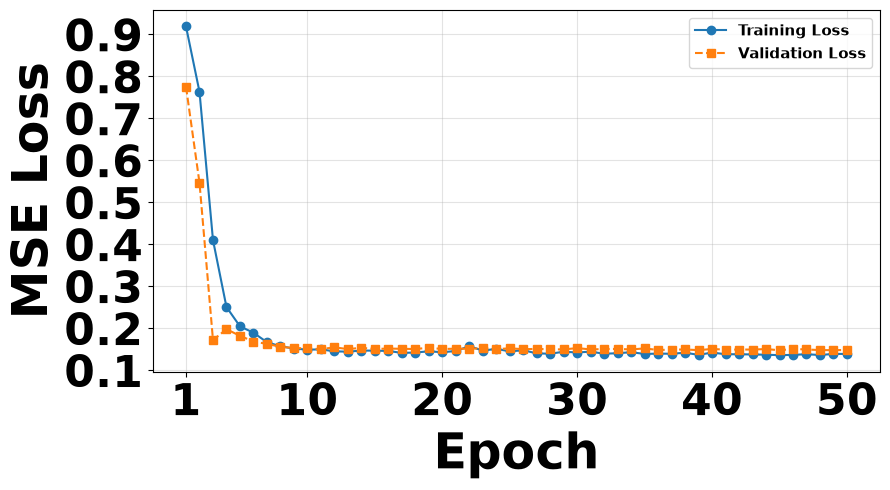

Final train loss : 0.138561
Final val   loss : 0.148053


In [37]:
plot_lstm_loss(lstm_history_2, dataset_label="dataset2", output_dir=str(PLOTS_DIR_2))

### LSTM Forecast for Day 40 — 9 May 2024 (Dataset 2)


Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_09_May_2024_dataset2.png


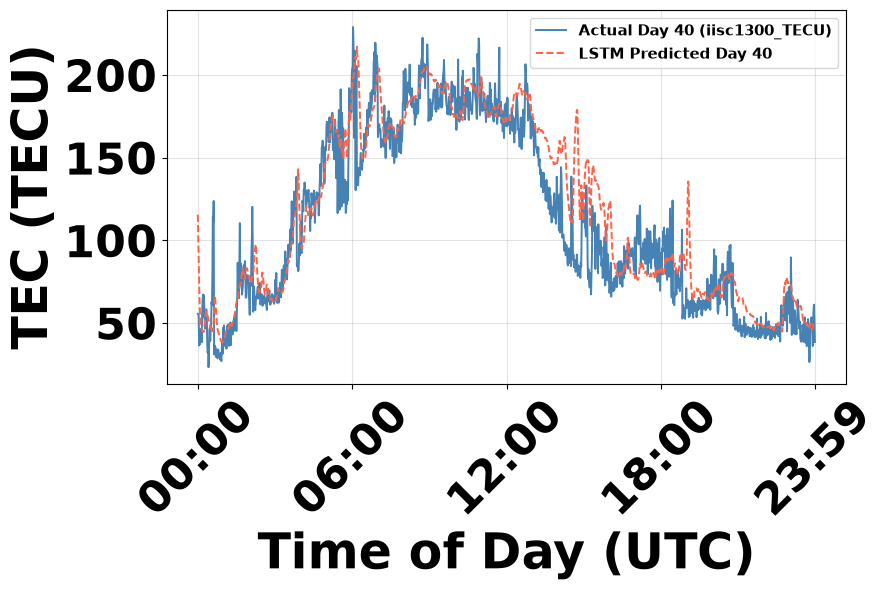

LSTM Day-40 RMSE : 20.8786 TECU
LSTM Day-40 MAE  : 14.8954 TECU


In [38]:
x_mean_2, x_std_2 = stats_2["x_mean"], stats_2["x_std"]
y_mean_2, y_std_2 = stats_2["y_mean"], stats_2["y_std"]

day39_raw_2 = daily_matrix_2[38]
actual40_2  = daily_matrix_2[39]

day39_in_2 = ((day39_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device = next(lstm_model_2.parameters()).device
src39  = torch.tensor(day39_in_2, dtype=torch.float32).to(device)

lstm_model_2.eval()
with torch.no_grad():
    pred40_norm_2 = lstm_model_2(src39).squeeze().cpu().numpy()   # (1440,)

lstm_pred40_2 = pred40_norm_2 * y_std_2 + y_mean_2

# derive label automatically from the loaded files
label_40_2 = f"Actual Day 40 ({daily_files_2[-2].stem.replace('_sorted', '')})"  # -> "Actual Day 40 (iisc1300_TECU)"

lstm_rmse_40_2, lstm_mae_40_2 = plot_lstm_prediction(
    actual40_2, lstm_pred40_2,
    actual_label=label_40_2, target_day=40, dataset_label="dataset2", date_label=get_date_label(2, 40),
    output_dir=str(PLOTS_DIR_2),
)

### LSTM Forecast for Day 41 — 10 May 2024 (Dataset 2)


Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_10_May_2024_dataset2.png


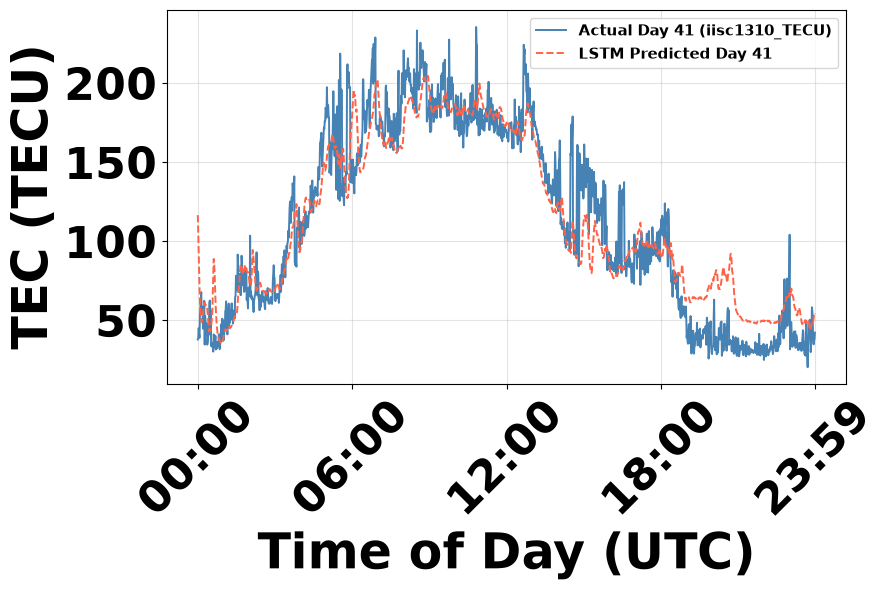

LSTM Day-41 RMSE : 21.7137 TECU
LSTM Day-41 MAE  : 16.7166 TECU


In [39]:
day40_raw_2 = daily_matrix_2[39]
actual41_2  = daily_matrix_2[40]

day40_in_2 = ((day40_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device = next(lstm_model_2.parameters()).device
src    = torch.tensor(day40_in_2, dtype=torch.float32).to(device)

lstm_model_2.eval()
with torch.no_grad():
    pred41_norm_2 = lstm_model_2(src).squeeze().cpu().numpy()   # (1440,)

lstm_pred41_2 = pred41_norm_2 * y_std_2 + y_mean_2

# derive label automatically from the loaded files
label_2 = f"Actual Day 41 ({daily_files_2[-1].stem.replace('_sorted', '')})"  # -> "Actual Day 41 (iisc1310_TECU)"

lstm_rmse_2, lstm_mae_2 = plot_lstm_prediction(
    actual41_2, lstm_pred41_2,
    actual_label=label_2, target_day=41, dataset_label="dataset2", date_label=get_date_label(2, 41),
    output_dir=str(PLOTS_DIR_2),
)

### Transformer Training Workflow for Dataset 2 — Day 40 to Day 41 Forecast (9–10 May 2024)

In [40]:
transformer_model_2, transformer_history_2 = train_transformer(X_train_2, y_train_2, X_val_2, y_val_2)

[Transformer] Training on: cpu
TECTransformerEncoder(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_proj): Linear(in_features=64, 

c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\src\models\transformer_model.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/50 | loss: 2.432968 | val_loss: 2.315245 | lr: 1.14e-05
Epoch   2/50 | loss: 2.291738 | val_loss: 1.992822 | lr: 2.29e-05
Epoch   3/50 | loss: 2.096118 | val_loss: 1.616904 | lr: 3.43e-05
Epoch   4/50 | loss: 1.857865 | val_loss: 1.291522 | lr: 4.57e-05
Epoch   5/50 | loss: 1.545233 | val_loss: 1.015654 | lr: 5.71e-05
Epoch   6/50 | loss: 1.227040 | val_loss: 0.749816 | lr: 6.86e-05
Epoch   7/50 | loss: 0.975755 | val_loss: 0.546308 | lr: 8.00e-05
Epoch   8/50 | loss: 0.753493 | val_loss: 0.405130 | lr: 9.14e-05
Epoch   9/50 | loss: 0.610369 | val_loss: 0.299508 | lr: 1.00e-04
Epoch  10/50 | loss: 0.484393 | val_loss: 0.233210 | lr: 9.97e-05
Epoch  11/50 | loss: 0.409757 | val_loss: 0.196059 | lr: 9.90e-05
Epoch  12/50 | loss: 0.371981 | val_loss: 0.176357 | lr: 9.79e-05
Epoch  13/50 | loss: 0.330522 | val_loss: 0.166706 | lr: 9.64e-05
Epoch  14/50 | loss: 0.324777 | val_loss: 0.158955 | lr: 9.46e-05
Epoch  15/50 | loss: 0.293176 | val_loss: 0.155053 | lr: 9.24e-05
Epoch  16/

### Transformer Loss and Validation Curve — Dataset 2 (9–10 May 2024)

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\loss_transformer_dataset2.png


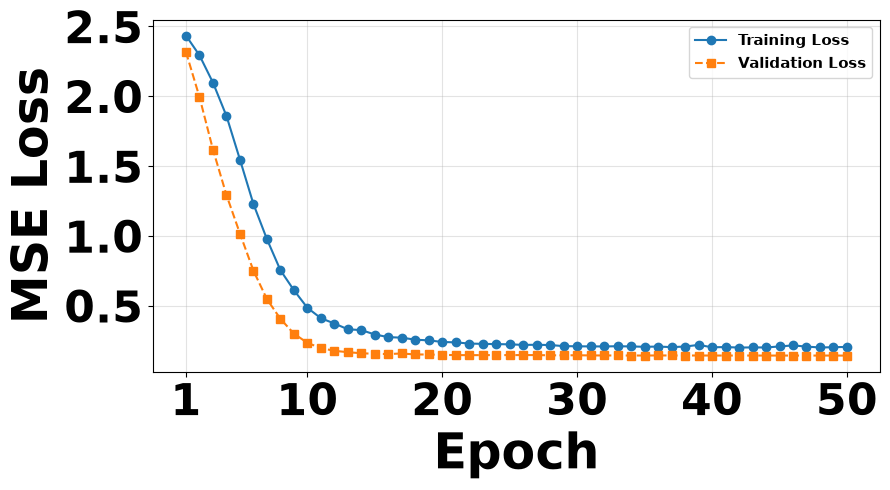

Final train loss : 0.204483
Final val   loss : 0.142177


In [41]:
plot_transformer_loss(transformer_history_2, dataset_label="dataset2", output_dir=str(PLOTS_DIR_2))

### Transformer Forecast for Day 40 — 9th May 2024 (Dataset 2)

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_09_May_2024_dataset2.png


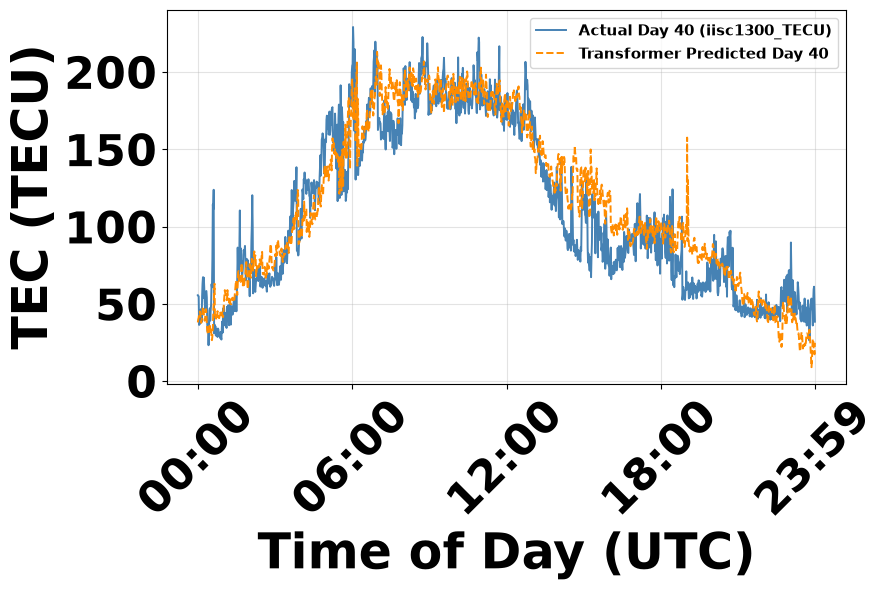

Transformer Day-40 RMSE : 19.8589 TECU
Transformer Day-40 MAE  : 15.4065 TECU


In [42]:
day39_in_t_2 = ((day39_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device   = next(transformer_model_2.parameters()).device
src39_t  = torch.tensor(day39_in_t_2, dtype=torch.float32).to(device)

transformer_model_2.eval()
with torch.no_grad():
    trans_pred40_norm_2 = transformer_model_2(src39_t).squeeze().cpu().numpy()   # (1440,)

trans_pred40_2 = trans_pred40_norm_2 * y_std_2 + y_mean_2
trans_rmse_40_2, trans_mae_40_2 = plot_transformer_prediction(
    actual40_2, trans_pred40_2,
    actual_label=label_40_2, target_day=40, dataset_label="dataset2", date_label=get_date_label(2, 40),
    output_dir=str(PLOTS_DIR_2),
)

### Transformer Forecast for Day 41 — 10 May 2024 (Dataset 2)

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_10_May_2024_dataset2.png


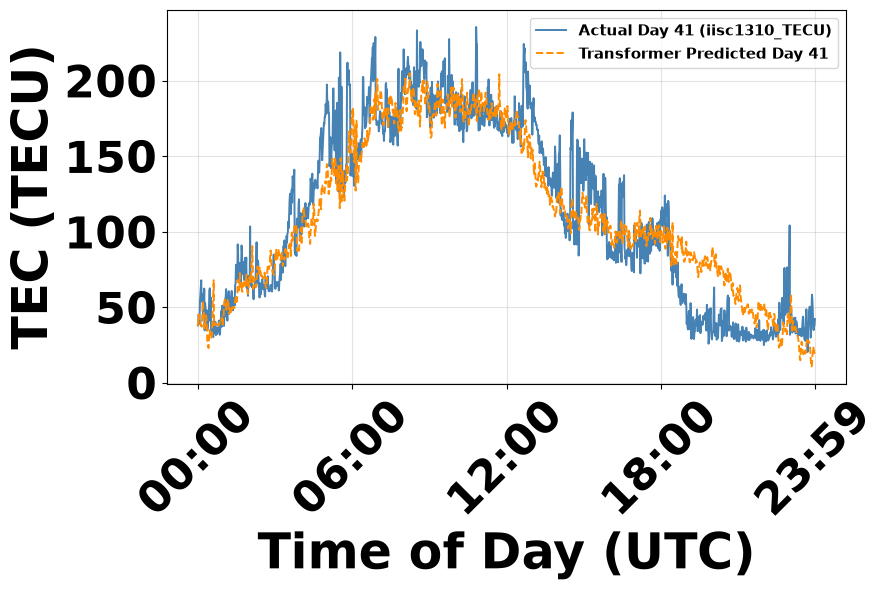

Transformer Day-41 RMSE : 22.3652 TECU
Transformer Day-41 MAE  : 17.5763 TECU


In [43]:
day40_in_t_2 = ((day40_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device  = next(transformer_model_2.parameters()).device
src_t_2 = torch.tensor(day40_in_t_2, dtype=torch.float32).to(device)

transformer_model_2.eval()
with torch.no_grad():
    trans_pred41_norm_2 = transformer_model_2(src_t_2).squeeze().cpu().numpy()   # (1440,)

trans_pred41_2 = trans_pred41_norm_2 * y_std_2 + y_mean_2
trans_rmse_2, trans_mae_2 = plot_transformer_prediction(
    actual41_2, trans_pred41_2,
    actual_label=label_2, target_day=41, dataset_label="dataset2", date_label=get_date_label(2, 41),
    output_dir=str(PLOTS_DIR_2),
)

### Model Comparison Summary for Day 40/41 Forecast — 9–10 May 2024 (Dataset 2)

In [44]:
print("=" * 60)
print(f"{'Model':<15} {'Target Day':<12} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 60)
print(f"{'LSTM':<15} {'Day 40':<12} {lstm_rmse_40_2:>12.4f} {lstm_mae_40_2:>12.4f}")
print(f"{'Transformer':<15} {'Day 40':<12} {trans_rmse_40_2:>12.4f} {trans_mae_40_2:>12.4f}")
print("-" * 60)
print(f"{'LSTM':<15} {'Day 41':<12} {lstm_rmse_2:>12.4f} {lstm_mae_2:>12.4f}")
print(f"{'Transformer':<15} {'Day 41':<12} {trans_rmse_2:>12.4f} {trans_mae_2:>12.4f}")
print("=" * 60)


Model           Target Day    RMSE (TECU)   MAE (TECU)
------------------------------------------------------------
LSTM            Day 40            20.8786      14.8954
Transformer     Day 40            19.8589      15.4065
------------------------------------------------------------
LSTM            Day 41            21.7137      16.7166
Transformer     Day 41            22.3652      17.5763


### Ionospheric Delay Analysis for LSTM Forecast — Day 40 (9 May 2024, Dataset 2)

LSTM Predicted L1 — RMSE: 3.39078 m   MAE: 2.41908 m
LSTM Predicted L5 — RMSE: 6.08059 m   MAE: 4.33807 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_09_May_2024_dataset2.png


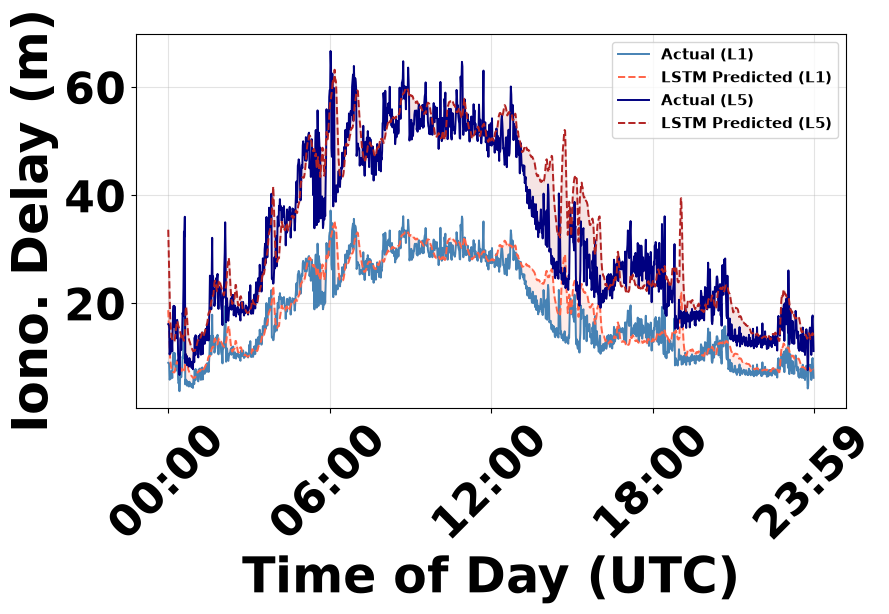

In [45]:
plot_lstm_delay_l1_l5_combined(actual40_2, lstm_pred40_2, target_day=40, dataset_label="dataset2", date_label=get_date_label(2, 40), output_dir=str(PLOTS_DIR_2))

### Ionospheric Delay Analysis for Transformer Forecast — Day 40 (9 May 2024, Dataset 2)

Transformer Predicted L1 — RMSE: 3.22517 m   MAE: 2.50209 m
Transformer Predicted L5 — RMSE: 5.78361 m   MAE: 4.48692 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_09_May_2024_dataset2.png


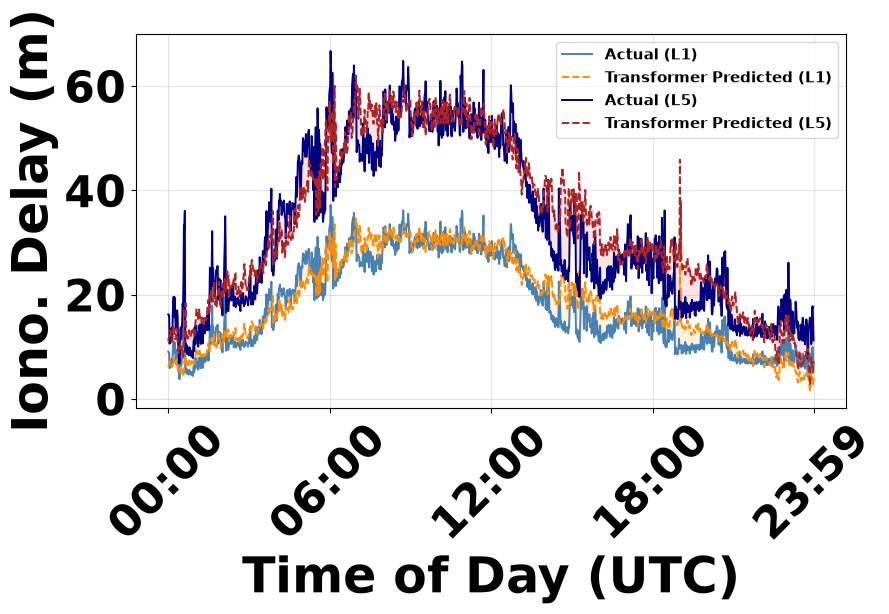

In [46]:
plot_transformer_delay_l1_l5_combined(actual40_2, trans_pred40_2, target_day=40, dataset_label="dataset2", date_label=get_date_label(2, 40), output_dir=str(PLOTS_DIR_2))

### Ionospheric Delay Analysis for LSTM Forecast — Day 41 (10 May 2024, Dataset 2)

LSTM Predicted L1 — RMSE: 3.52641 m   MAE: 2.71486 m
LSTM Predicted L5 — RMSE: 6.32381 m   MAE: 4.86848 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_10_May_2024_dataset2.png


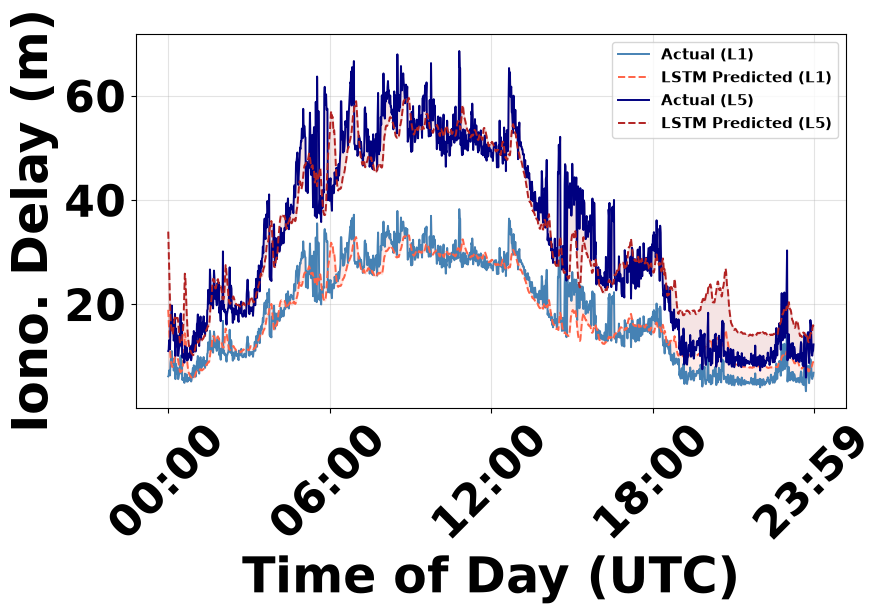

In [47]:
plot_lstm_delay_l1_l5_combined(actual41_2, lstm_pred41_2, target_day=41, dataset_label="dataset2", date_label=get_date_label(2, 41), output_dir=str(PLOTS_DIR_2))

### Ionospheric Delay Analysis for Transformer Forecast — Day 41 (10 May 2024, Dataset 2)

Transformer Predicted L1 — RMSE: 3.63222 m   MAE: 2.85447 m


Transformer Predicted L5 — RMSE: 6.51355 m   MAE: 5.11884 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_10_May_2024_dataset2.png


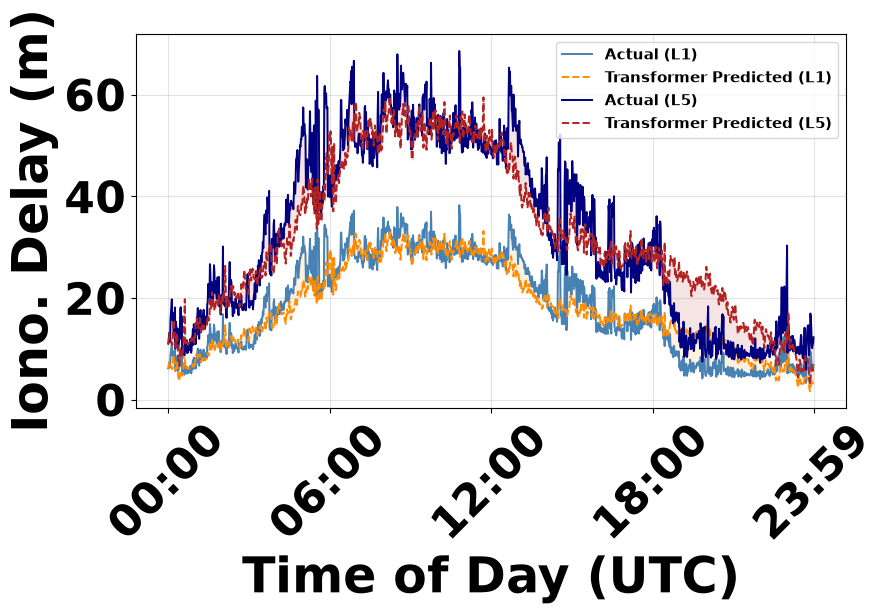

In [48]:
plot_transformer_delay_l1_l5_combined(actual41_2, trans_pred41_2, target_day=41, dataset_label="dataset2", date_label=get_date_label(2, 41), output_dir=str(PLOTS_DIR_2))

### Delay Error Metrics for Day 40/41 Forecast — 9–10 May 2024 (Dataset 2)

In [49]:
iono_actual41_2 = tec_to_iono_delay(actual41_2)
iono_lstm41_2   = tec_to_iono_delay(lstm_pred41_2)
iono_trans41_2  = tec_to_iono_delay(trans_pred41_2)

iono_actual40_2 = tec_to_iono_delay(actual40_2)
iono_lstm40_2   = tec_to_iono_delay(lstm_pred40_2)
iono_trans40_2  = tec_to_iono_delay(trans_pred40_2)

print("Ionospheric Delay Error (L1, vertical) — Day 40 — Dataset 2")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm40_2,  iono_actual40_2)
delay_metrics("Transformer", iono_trans40_2, iono_actual40_2)

print()
print("Ionospheric Delay Error (L1, vertical) — Day 41 — Dataset 2")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm41_2,  iono_actual41_2)
delay_metrics("Transformer", iono_trans41_2, iono_actual41_2)


Ionospheric Delay Error (L1, vertical) — Day 40 — Dataset 2
LSTM             RMSE = 3.39078 m   MAE = 2.41908 m   Bias = +1.14771 m
Transformer      RMSE = 3.22517 m   MAE = 2.50209 m   Bias = +0.72244 m

Ionospheric Delay Error (L1, vertical) — Day 41 — Dataset 2
LSTM             RMSE = 3.52641 m   MAE = 2.71486 m   Bias = +0.10320 m
Transformer      RMSE = 3.63222 m   MAE = 2.85447 m   Bias = -0.26904 m


{'name': 'Transformer',
 'rmse': 3.6322176456451416,
 'mae': 2.854469060897827,
 'bias': -0.26904067397117615}

### Save Forecast Output CSV — Day 40 (9 May 2024, Dataset 2)

In [50]:
save_delay_csv(actual40_2, lstm_pred40_2, trans_pred40_2, output_dir=OUTPUT_DIR_2, filename="day40_ionospheric_delay.csv")

Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day40_ionospheric_delay.csv


### Save Forecast Output CSV — Day 41 (10 May 2024, Dataset 2)


In [51]:
save_delay_csv(actual41_2, lstm_pred41_2, trans_pred41_2, output_dir=OUTPUT_DIR_2, filename="day41_ionospheric_delay.csv")

Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day41_ionospheric_delay.csv


In [52]:
lstm_rmse_metric_2 = rmse(lstm_pred41_2, actual41_2)
transformer_rmse_metric_2 = rmse(trans_pred41_2, actual41_2)

print(f"LSTM RMSE:        {lstm_rmse_metric_2:.4f} TECU")
print(f"Transformer RMSE: {transformer_rmse_metric_2:.4f} TECU")


LSTM RMSE:        21.7137 TECU
Transformer RMSE: 22.3652 TECU


In [53]:
lstm_correlation_2 = pearson_correlation(lstm_pred41_2, actual41_2)
transformer_correlation_2 = pearson_correlation(trans_pred41_2, actual41_2)

print("Dataset 2 — Day 41")
print(f"LSTM correlation:        {lstm_correlation_2:.4f}")
print(f"Transformer correlation: {transformer_correlation_2:.4f}")


Dataset 2 — Day 41
LSTM correlation:        0.9364
Transformer correlation: 0.9298


In [54]:
storm_threshold_2 = float(
    np.percentile(daily_matrix_2[1:30], EVENT_THRESHOLD_PERCENTILE)
)

print(f"Dataset 2 threshold: {storm_threshold_2:.2f} TECU")


Dataset 2 threshold: 152.56 TECU


In [55]:
lstm_pod_2 = probability_of_detection(
    lstm_pred41_2, actual41_2, threshold=storm_threshold_2
)
transformer_pod_2 = probability_of_detection(
    trans_pred41_2, actual41_2, threshold=storm_threshold_2
)

print("Dataset 2 — Day 41 POD")
print(f"LSTM POD:        {lstm_pod_2:.4f}")
print(f"Transformer POD: {transformer_pod_2:.4f}")


Dataset 2 — Day 41 POD
LSTM POD:        0.8796
Transformer POD: 0.8102


In [56]:
lstm_csi_2 = critical_success_index(
    lstm_pred41_2, actual41_2, threshold=storm_threshold_2
)
transformer_csi_2 = critical_success_index(
    trans_pred41_2, actual41_2, threshold=storm_threshold_2
)

print("Dataset 2 — Day 41 CSI")
print(f"LSTM CSI:        {lstm_csi_2:.4f}")
print(f"Transformer CSI: {transformer_csi_2:.4f}")


Dataset 2 — Day 41 CSI
LSTM CSI:        0.8304
Transformer CSI: 0.7924


In [57]:
lstm_f1_2 = f1_score(
    lstm_pred41_2, actual41_2, threshold=storm_threshold_2
)
transformer_f1_2 = f1_score(
    trans_pred41_2, actual41_2, threshold=storm_threshold_2
)

print("Dataset 2 — Day 41 F1 score")
print(f"LSTM F1:        {lstm_f1_2:.4f}")
print(f"Transformer F1: {transformer_f1_2:.4f}")


Dataset 2 — Day 41 F1 score
LSTM F1:        0.9074
Transformer F1: 0.8842


In [58]:
lstm_far_2 = false_alarm_ratio(
    lstm_pred41_2, actual41_2, threshold=storm_threshold_2
)
transformer_far_2 = false_alarm_ratio(
    trans_pred41_2, actual41_2, threshold=storm_threshold_2
)

print("Dataset 2 — Day 41 FAR")
print(f"LSTM FAR:        {lstm_far_2:.4f}")
print(f"Transformer FAR: {transformer_far_2:.4f}")


Dataset 2 — Day 41 FAR
LSTM FAR:        0.0630
Transformer FAR: 0.0270


In [59]:
# --- RMSE & Correlation on Ionospheric Delay — L1 & L5, LSTM vs Transformer (Dataset 2) ---

from src.utils.iono_delay import compute_all_delays

freqs = {"L1": F_L1, "L5": F_L5}

actual_tec, lstm_tec, trans_tec = actual41_2, lstm_pred41_2, trans_pred41_2

delay_rows = []

for freq_label, freq_hz in freqs.items():

    # Convert TEC -> vertical ionospheric delay (metres) at this frequency
    actual_delay, lstm_delay, trans_delay = compute_all_delays(
        actual_tec, lstm_tec, trans_tec, frequency=freq_hz
    )

    for model_name, pred_delay in (
        ("LSTM", lstm_delay),
        ("Transformer", trans_delay),
    ):
        delay_rmse = rmse(pred_delay, actual_delay)
        delay_corr = pearson_correlation(pred_delay, actual_delay)

        delay_rows.append({
            "Frequency": freq_label,
            "Model": model_name,
            "RMSE (m)": delay_rmse,
            "Correlation": delay_corr,
        })

        print(
            f"{freq_label:<3} | {model_name:<12} "
            f"| RMSE: {delay_rmse:.4f} m | Corr: {delay_corr:.4f}"
        )

iono_delay_metrics_table_2 = pd.DataFrame(delay_rows).round(4)
iono_delay_metrics_table_2

L1  | LSTM         | RMSE: 3.5264 m | Corr: 0.9364
L1  | Transformer  | RMSE: 3.6322 m | Corr: 0.9298
L5  | LSTM         | RMSE: 6.3238 m | Corr: 0.9364
L5  | Transformer  | RMSE: 6.5135 m | Corr: 0.9298


,Frequency,Model,RMSE (m),Correlation
0,L1,LSTM,3.5264,0.9364
1,L1,Transformer,3.6322,0.9298
2,L5,LSTM,6.3238,0.9364
3,L5,Transformer,6.5135,0.9298


---
## Summary — Metrics Table (Dataset 2, Day 41)
```text
Consolidates every metric computed above (RMSE, Correlation, POD, CSI,
F1 score, FAR) for both models (LSTM, Transformer) for Dataset 2
into a single comparison table, and writes it to CSV for the paper.
```

In [60]:
metrics_summary = pd.DataFrame({
    "Dataset": ["Dataset 2", "Dataset 2"],
    "Model": ["LSTM", "Transformer"],
    "RMSE (TECU)": [
        lstm_rmse_metric_2, transformer_rmse_metric_2,
    ],
    "Correlation": [
        lstm_correlation_2, transformer_correlation_2,
    ],
    "POD": [
        lstm_pod_2, transformer_pod_2,
    ],
    "CSI": [
        lstm_csi_2, transformer_csi_2,
    ],
    "F1 Score": [
        lstm_f1_2, transformer_f1_2,
    ],
    "FAR": [
        lstm_far_2, transformer_far_2,
    ],
}).round(4)

print("=" * 80)
print("Day 41 Forecast — Summary Metrics Table (Dataset 2)")
print("=" * 80)
print(metrics_summary.to_string(index=False))

summary_csv_path = GENERATED_PLOTS_DIR / "metrics_summary_day41_dataset2.csv"
GENERATED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
metrics_summary.to_csv(summary_csv_path, index=False)
print(f"\nSaved summary table to: {summary_csv_path}")

metrics_summary


Day 41 Forecast — Summary Metrics Table (Dataset 2)
  Dataset       Model  RMSE (TECU)  Correlation    POD    CSI  F1 Score   FAR
Dataset 2        LSTM      21.7137       0.9364 0.8796 0.8304    0.9074 0.063
Dataset 2 Transformer      22.3652       0.9298 0.8102 0.7924    0.8842 0.027

Saved summary table to: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\metrics_summary_day41_dataset2.csv


,Dataset,Model,RMSE (TECU),Correlation,POD,CSI,F1 Score,FAR
0,Dataset 2,LSTM,21.7137,0.9364,0.8796,0.8304,0.9074,0.063
1,Dataset 2,Transformer,22.3652,0.9298,0.8102,0.7924,0.8842,0.027
